## **Bank Nifty SPP Sentiment Analysis — PhD Research (SPPU)**

### **NB-P1-01 — Pipeline 1: Feature Engineering (Technical Indicators + Binary Direction Targets + Splits)**

[![Python](https://img.shields.io/badge/Python-3.10%2B-blue)](https://www.python.org/) [![pandas](https://img.shields.io/badge/Pandas-2.x-green)](https://pandas.pydata.org/) [![ta](https://img.shields.io/badge/ta-0.11-orange)](https://technical-analysis-library-in-python.readthedocs.io/) [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT) [![Author](https://img.shields.io/badge/Author-Prakash%20Ukhalkar-informational)](https://github.com/prakash-ukhalkar)

---

**Purpose:** Slice the 5-year P1 study window (01 Apr 2021 – 31 Mar 2026) from the shared Bank Nifty OHLCV, compute 14 technical indicators, create lagged-return features, engineer **binary directional targets** (`dir_Nd = 1 if close[t+N] > close[t] else 0`) for horizons **1-day / 5-day / 21-day**, perform temporal train/val/test splitting, and save the processed feature set and split indices.

**Dataset Scope:** Feature engineering only — no model training, no sentiment scoring.

> **All four pipelines (P1–P4) use binary directional classification targets. Scale-invariant — no extrapolation failure possible.**

---


### **Pipeline Context**

**Pipeline 1 (P1) — 5-Year Technical Baseline**

| Stage | Notebook | Status |
|---|---|---|
| Feature Engineering | **NB-P1-01** ← *You are here* | — |
| Tree Ensemble Models | NB-P1-02 | Depends on NB-P1-01 |
| BiLSTM + Self-Attention | NB-P1-03 | Depends on NB-P1-01 |
| OOF Stacking Ensemble | NB-P1-04 | Depends on NB-P1-02, NB-P1-03 |
| Results & Visualisation | NB-P1-05 | Depends on NB-P1-04 |

**Final Model Architecture (P1)**

| Component | Detail |
|---|---|
| Window | 5-Year (2021-04-01 → 2026-03-31) |
| Modality | Technical only (no sentiment, no GDELT) |
| Tree Ensemble | RF · XGB · LGB · CatBoost |
| Sequence Model | BiLSTM + Self-Attention |
| Ensemble | OOF Stack (LR meta) |
| Horizons | 1-day, 5-day, 21-day directional |

**Prerequisites:** NB-S01 (banknifty_raw.parquet must exist in `data/raw/market/`)

---

**PhD Research Project**  
**Researcher**: Prakash Ukhalkar  
**Supervisors**: Dr. Ravikant Zirmite, Dr. Manasi Bhate  
**Version**: 4.0 (SPP Multi-Pipeline Study)  
**Status**: Execution Ready

## 1. Introduction

### 1.1 Purpose of This Notebook

This notebook is the **first pipeline-specific stage** for Pipeline 1. It reads the immutable raw market data produced by NB-S01, extracts the 5-year P1 window, and transforms it into a model-ready feature matrix with binary directional classification targets.

### 1.2 Technical Indicators Computed (16 stored; 14 used in models)

| Group | Indicators |
|---|---|
| Trend | MACD, MACD Signal, MACD Histogram, EMA-20 |
| Momentum | RSI-14, Stochastic %K, Stochastic %D, ROC-10 |
| Volatility | BB Upper, BB Lower, BB Width, ATR-14 |
| Volume | OBV, OBV Z-score *(stored only — see note below)* |

> **Note on OBV / OBV Z-score:** These two features are computed and stored in the output parquet for completeness, but are **excluded from all model notebooks (NB-P1-02 onward)**. Bank Nifty is a price index with zero traded volume — OBV derived from a constant-zero volume series carries no signal and would only add noise to the feature matrix. The effective model feature count is therefore **16** (12 indicator columns + 4 lagged returns), not 18.

### 1.3 Lagged Return Features

Daily percentage returns lagged by 1, 2, 3, and 5 days are appended as additional features to capture short-term price momentum.

### 1.4 Target Variables (Binary Direction Classification)

All four pipelines (P1–P4) predict binary directional movement — a classification task:
- `dir_1d = 1` if `Close[t+1] > Close[t]` else `0` — next-day direction
- `dir_5d = 1` if `Close[t+5] > Close[t]` else `0` — 5-day direction
- `dir_21d = 1` if `Close[t+21] > Close[t]` else `0` — 21-day direction

Targets are **scale-invariant**: no extrapolation failure possible. Coin-flip baseline = 50%.

### 1.5 Temporal Split Strategy

Strictly chronological split — no shuffling:
- **Train**: first 70% — 819 trading days (2021-05-24 → 2024-10-24)
- **Val**: next 15% — 170 trading days (2024-11-01 → 2025-07-10)
- **Test**: last 15% — 172 trading days (2025-07-18 → 2026-03-30)

A 5-day purge gap is applied at each split boundary to prevent lookahead leakage.

### 1.6 Scope Boundaries (What This Notebook Does NOT Do)

| Task | Deferred to |
|---|---|
| Model training | NB-P1-02 (tree), NB-P1-03 (BiLSTM) |
| Feature selection / importance | NB-P1-02, NB-P1-05 |
| Sentiment features | P3 / P4 only |
| Walk-forward splits | NB-P1-04 |
| SHAP explanations | NB-P1-05 |


## 2. Libraries & Configuration

### 2.1 Library Imports and Protocol Constants

**Purpose:** Import all required libraries and lock the protocol constants for the 5-year P1 study window.

**Key Points:**
- No ML libraries imported in this notebook
- `src.features.technical.compute_all_indicators` handles all 14 indicators via the `ta` library
- `src.features.target` provides `make_target`, `make_deadband_mask`, `make_return_features`
- `src.features.splits.temporal_split` performs the 70/15/15 chronological split with purge gap
- All constants derived from `config.yaml` + `p1_config.yaml` — never hard-coded inline

In [1]:
# ── Standard Libraries ─────────────────────────────────────────────────────
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# ── Project src path ───────────────────────────────────────────────────────
sys.path.insert(0, str(Path('..').resolve().parent))

from src.utils.reproducibility import set_all_seeds
from src.utils.config import load_config, get_pipeline_config
from src.utils.logging import setup_logger

set_all_seeds(42)
setup_logger()
cfg    = load_config()
p1_cfg = get_pipeline_config('p1')

# ── Protocol Constants ─────────────────────────────────────────────────────
PIPELINE       = 'P1'
START_DATE     = cfg['study_windows']['p1_p3']['start']   # '2021-04-01'
END_DATE       = cfg['study_windows']['p1_p3']['end']     # '2026-03-31'
HORIZONS       = cfg['target']['horizon']                 # [1, 5, 21]
RANDOM_STATE   = cfg['seed']                              # 42
TRAIN_RATIO    = cfg['split']['train_ratio']              # 0.70
VAL_RATIO      = cfg['split']['val_ratio']                # 0.15
TEST_RATIO     = cfg['split']['test_ratio']               # 0.15
PURGE_GAP      = cfg['split']['purge_gap']                # 5

# ── Paths ──────────────────────────────────────────────────────────────────
RAW_DIR        = Path('../data/raw/market')
PROCESSED_DIR  = Path('../data/processed/p1')
SPLITS_DIR     = Path('../data/splits')
PLOTS_DIR      = Path('../plots/p1')

print(f'[OK] Configuration loaded — {PIPELINE}')
print(f'  Study window : {START_DATE} → {END_DATE}')
print(f'  Horizons     : {HORIZONS} trading days')
print(f'  Split ratios : {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}')
print(f'  Purge gap    : {PURGE_GAP} days')
print(f'  Random seed  : {RANDOM_STATE}')


[OK] Configuration loaded — P1
  Study window : 2021-04-01 → 2026-03-31
  Horizons     : [1, 5, 21] trading days
  Split ratios : 0.7/0.15/0.15
  Purge gap    : 21 days
  Random seed  : 42


## 3. Directory Setup

### 3.1 Ensure Output Directories Exist

**Purpose:** Create `data/processed/p1/`, `data/splits/`, and `plots/p1/` if they do not already exist.

In [2]:
for d in [PROCESSED_DIR, SPLITS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f'  [OK] {d}')
print('\n[OK] All output directories ready.')

  [OK] ..\data\processed\p1
  [OK] ..\data\splits
  [OK] ..\plots\p1

[OK] All output directories ready.


## 4. Load & Slice Raw Market Data

### 4.1 Load Bank Nifty OHLCV — 5-Year P1 Window

**Purpose:** Load the shared `banknifty_raw.parquet` and slice to the P1 study window (2021-04-01 → 2026-03-31).

**Key Points:**
- Source parquet is **never modified** — only read
- Date slicing uses inclusive boundaries aligned to NSE trading days
- Columns retained: `Open`, `High`, `Low`, `Close`, `Volume`

In [3]:
BN_PATH = RAW_DIR / 'banknifty_raw.parquet'
assert BN_PATH.exists(), f'[FAIL] {BN_PATH} not found. Run NB-S01 first.'

raw_df = pd.read_parquet(BN_PATH)
raw_df.index = pd.to_datetime(raw_df.index)

# Slice to P1 5-year window
df = raw_df.loc[START_DATE:END_DATE].copy()

print(f'[OK] Raw data loaded: {len(raw_df):,} total trading days')
print(f'[OK] P1 slice       : {len(df):,} trading days')
print(f'  Date range   : {df.index.min().date()} → {df.index.max().date()}')
print(f'  Columns      : {list(df.columns)}')
print(f'  Close range  : ₹{df["Close"].min():,.0f} – ₹{df["Close"].max():,.0f}')
print()
df.head()

[OK] Raw data loaded: 2,465 total trading days
[OK] P1 slice       : 1,233 trading days
  Date range   : 2021-04-01 → 2026-03-30
  Columns      : ['Close', 'High', 'Low', 'Open', 'Volume']
  Close range  : ₹30,792 – ₹61,551



,Close,High,Low,Open,Volume
Date,,,,,
2021-04-01,33857.605469,33948.752844,33208.363034,33587.608615,0
2021-04-05,32678.470703,33697.359280,32329.775527,33648.758281,0
2021-04-06,32500.972656,33007.265612,32338.025327,32915.266679,0
2021-04-07,32990.816406,33191.314080,32141.177828,32529.321761,0
2021-04-08,32782.468750,33306.411850,32704.368100,33153.812070,0


### 4.2 Bank Nifty Price & Volume Trend — P1 Study Window

**Purpose:** Visualise the Bank Nifty Close price with Hi/Lo range and a 20-day moving average overlay, alongside the daily volume bar chart, for the 5-year P1 window.


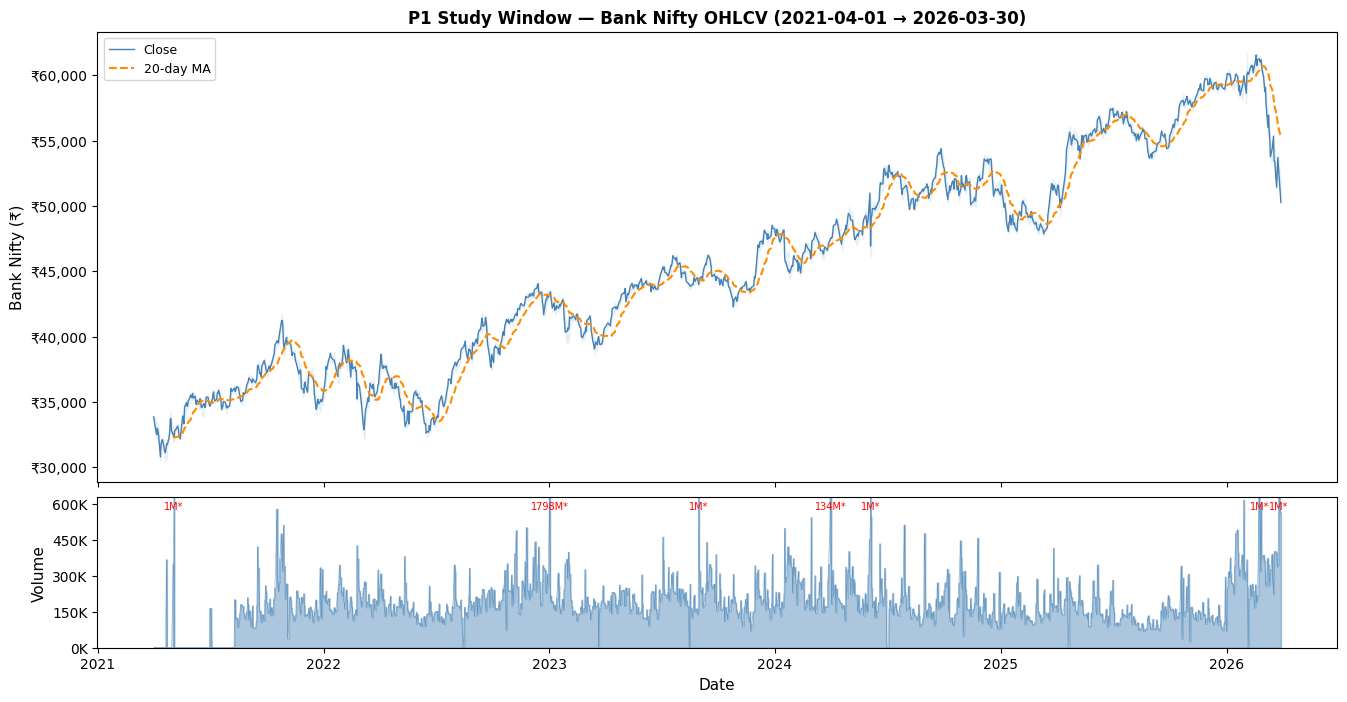

[OK] Saved: p1_price_trend.png
[INFO] 7 volume outlier(s) exceed 99th pct cap (1M) — marked with * on chart
                Volume
Date                  
2021-05-04      786800
2023-01-02  1798102100
2023-08-31      705100
2024-04-01   134089400
2024-06-04      653100
2026-02-23      841900
2026-03-27      653000


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 4.2 Bank Nifty Price & Volume Trend — P1 Window ───────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# ── Close price with 20-day rolling mean overlay ───────────────────────
ax1.plot(df.index, df['Close'], color='steelblue', linewidth=1.0, label='Close')
ax1.plot(df.index, df['Close'].rolling(20).mean(), color='darkorange',
         linewidth=1.5, linestyle='--', label='20-day MA')
ax1.fill_between(df.index, df['Low'], df['High'], alpha=0.08, color='steelblue')
ax1.set_ylabel('Bank Nifty (₹)', fontsize=11)
ax1.set_title(f'P1 Study Window — Bank Nifty OHLCV ({df.index.min().date()} → {df.index.max().date()})',
              fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax1.legend(fontsize=9)

# ── Volume — cap y-axis at 99th pct to prevent outlier compression ──────
vol_cap = df['Volume'].quantile(0.99) * 1.15
ax2.fill_between(df.index, df['Volume'].clip(upper=vol_cap), color='steelblue', alpha=0.45, step='mid')
ax2.plot(df.index, df['Volume'].clip(upper=vol_cap), color='steelblue', linewidth=0.4, alpha=0.6)
ax2.set_ylim(0, vol_cap)
ax2.set_ylabel('Volume', fontsize=11)
# Use 5 evenly-spaced ticks; format with enough decimals so no two labels collide
ax2.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, min_n_ticks=4))
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}K')
)
ax2.set_xlabel('Date', fontsize=11)

# Annotate any days that exceeded the cap
outliers = df[df['Volume'] > vol_cap]
for dt, row in outliers.iterrows():
    ax2.annotate(f'{row["Volume"]/1e6:.0f}M*',
                 xy=(dt, vol_cap), xytext=(dt, vol_cap * 0.92),
                 fontsize=7, color='red', ha='center')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p1_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()

outlier_count = len(outliers)
print(f'[OK] Saved: p1_price_trend.png')
if outlier_count:
    print(f'[INFO] {outlier_count} volume outlier(s) exceed 99th pct cap '
          f'({vol_cap/1e6:.0f}M) — marked with * on chart')
    print(outliers[['Volume']].to_string())


## 5. Technical Indicators

### 5.1 Compute All 14 Indicators

**Purpose:** Compute the full set of 14 technical indicators using `src.features.technical.compute_all_indicators`.

**Key Points:**
- All indicators use closing-price data only or OHLCV as required
- Indicator warmup periods (up to 26 bars) will produce NaN in early rows — these are dropped after all features are assembled
- No future data is used in any indicator calculation (all backward-looking windows)

In [5]:
from src.features.technical import compute_all_indicators

df = compute_all_indicators(df)

INDICATOR_COLS = [
    'macd', 'macd_signal', 'macd_diff', 'ema_20',
    'rsi_14', 'stoch_k', 'stoch_d', 'roc_10',
    'bb_upper', 'bb_lower', 'bb_width', 'atr_14',
    'obv', 'obv_zscore',
]

print(f'[OK] Technical indicators computed: {len(INDICATOR_COLS)} features')
print()
for col in INDICATOR_COLS:
    nan_count = df[col].isna().sum()
    print(f'  {col:<18} | NaN warmup rows: {nan_count:>3} | mean: {df[col].mean():.4f}')

print(f'\n[OK] DataFrame shape after indicators: {df.shape}')

[OK] Technical indicators computed: 14 features

  macd               | NaN warmup rows:  25 | mean: 141.2082
  macd_signal        | NaN warmup rows:  33 | mean: 147.7023
  macd_diff          | NaN warmup rows:  33 | mean: -6.0124
  ema_20             | NaN warmup rows:  19 | mean: 45480.6702
  rsi_14             | NaN warmup rows:  13 | mean: 53.7037
  stoch_k            | NaN warmup rows:  13 | mean: 57.6458
  stoch_d            | NaN warmup rows:  15 | mean: 57.6988
  roc_10             | NaN warmup rows:  10 | mean: 0.4648
  bb_upper           | NaN warmup rows:  19 | mean: 47016.7304
  bb_lower           | NaN warmup rows:  19 | mean: 43957.7595
  bb_width           | NaN warmup rows:  19 | mean: 6.9545
  atr_14             | NaN warmup rows:   0 | mean: 625.0507
  obv                | NaN warmup rows:   0 | mean: 1224168150.6894
  obv_zscore         | NaN warmup rows:  48 | mean: 0.3005

[OK] DataFrame shape after indicators: (1233, 19)


## 6. Lagged Return Features

### 6.1 Compute Lagged Daily Returns

**Purpose:** Append lagged percentage-return features (lags 1, 2, 3, 5 days) to capture short-term price momentum directly in the feature matrix.

**Key Points:**
- Returns are computed as `Close.pct_change(lag)` — backward-looking, no lookahead
- Combined with technical indicators these form the full P1 feature vector

In [6]:
from src.features.target import make_return_features

RETURN_LAGS = [1, 2, 3, 5]
ret_df = make_return_features(df['Close'], lags=RETURN_LAGS)
df = pd.concat([df, ret_df], axis=1)

RETURN_COLS = [f'return_lag_{lag}' for lag in RETURN_LAGS]
print(f'[OK] Lagged return features added: {RETURN_COLS}')
print(f'[OK] DataFrame shape: {df.shape}')

[OK] Lagged return features added: ['return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5']
[OK] DataFrame shape: (1233, 23)


## 7. Target Variables — Binary Directional Direction

### 7.1 Create Binary Directional Targets (Horizons: 1, 5, 21 trading days)

**Purpose:** Create binary directional targets for all three prediction horizons.

**Key Points:**
- `dir_1d = 1` if `Close[t+1] > Close[t]` else `0` — next-day price movement direction
- `dir_5d = 1` if `Close[t+5] > Close[t]` else `0` — 5-day price movement direction
- `dir_21d = 1` if `Close[t+21] > Close[t]` else `0` — 21-day price movement direction
- Last `horizon` rows are NaN (no future data available) — dropped before training
- Binary targets are **scale-invariant** — no extrapolation failure possible; 50% coin-flip baseline
- All four pipelines (P1–P4) use binary directional targets, making cross-pipeline comparisons consistent


In [7]:
from src.features.target import make_target

TARGET_COLS = []
for h in HORIZONS:
    col = f'dir_{h}d'
    df[col] = make_target(df['Close'], horizon=h, label_col=col)
    TARGET_COLS.append(col)

print('[OK] Binary directional targets created:')
for col in TARGET_COLS:
    valid = df[col].dropna()
    n_up   = int(valid.sum())
    n_down = int(len(valid) - n_up)
    print(f'  {col:<12} | valid rows: {len(valid):,} | '
          f'Up (1): {n_up:,} ({n_up/len(valid)*100:.1f}%) | '
          f'Down (0): {n_down:,} ({n_down/len(valid)*100:.1f}%)')

print(f'\n[OK] DataFrame shape: {df.shape}')


[OK] Binary directional targets created:
  dir_1d       | valid rows: 1,232 | Up (1): 653 (53.0%) | Down (0): 579 (47.0%)
  dir_5d       | valid rows: 1,228 | Up (1): 682 (55.5%) | Down (0): 546 (44.5%)
  dir_21d      | valid rows: 1,212 | Up (1): 739 (61.0%) | Down (0): 473 (39.0%)

[OK] DataFrame shape: (1233, 26)


## 8. Data Cleaning & Feature Matrix

### 8.1 Drop Warmup NaN Rows and Finalise Feature Columns

**Purpose:** Remove rows with NaN values from indicator warmup periods and finalise the full feature column list.

**Key Points:**
- NaN rows are dropped from the front of the dataset (indicator warmup effect)
- Target NaN rows (last `max_horizon` rows) are **kept in the feature file** — each model notebook handles horizon-specific target dropna
- `FEATURE_COLS` is the canonical feature list written into the parquet metadata

In [8]:
FEATURE_COLS = INDICATOR_COLS + RETURN_COLS

# Drop warmup NaN rows (only from feature columns, not target columns)
pre_clean = len(df)
df = df.dropna(subset=FEATURE_COLS).copy()
post_clean = len(df)

print(f'[OK] Rows before NaN drop : {pre_clean:,}')
print(f'[OK] Rows after NaN drop  : {post_clean:,}  (dropped {pre_clean - post_clean} warmup rows)')
print(f'[OK] Feature columns      : {len(FEATURE_COLS)}')
print(f'[OK] Target columns       : {TARGET_COLS}')
print(f'[OK] Final shape          : {df.shape}')
print()

# Summary statistics for feature columns
df[FEATURE_COLS].describe().round(4)

[OK] Rows before NaN drop : 1,233
[OK] Rows after NaN drop  : 1,171  (dropped 62 warmup rows)
[OK] Feature columns      : 18
[OK] Target columns       : ['dir_1d', 'dir_5d', 'dir_21d']
[OK] Final shape          : (1171, 26)



,macd,macd_signal,macd_diff,ema_20,rsi_14,stoch_k,stoch_d,roc_10,bb_upper,bb_lower,bb_width,atr_14,obv,obv_zscore,return_lag_1,return_lag_2,return_lag_3,return_lag_5
count,1171.0000,1171.0000,1171.0000,1171.0000,1171.0000,1171.0000,1171.0000,1171.0000,1171.0000,1171.0000,1171.0000,1171.0000,1.171000e+03,1171.0000,1171.0000,1171.0000,1171.0000,1171.0000
mean,136.9784,142.6002,-5.6218,45898.1652,53.6608,57.4312,57.5156,0.4468,47445.0745,44367.4436,6.9328,628.2963,1.289009e+09,0.3211,0.0004,0.0008,0.0012,0.0020
std,481.7488,431.8870,164.0355,7556.2141,12.1006,30.0342,28.0630,3.4283,7581.6093,7675.2899,3.5143,147.9179,8.821042e+08,1.3045,0.0106,0.0150,0.0184,0.0240
min,-2042.0648,-1704.9964,-706.6730,33292.2215,22.9558,1.0476,2.2684,-12.5745,34645.5617,31525.5495,1.4037,375.1738,-1.046000e+06,-4.2485,-0.0795,-0.0639,-0.0707,-0.0977
25%,-173.3427,-161.9850,-105.7412,39252.7403,44.8303,30.2720,32.7767,-1.6504,41295.2780,37398.9527,4.4157,510.2377,3.837350e+06,-0.7649,-0.0050,-0.0069,-0.0086,-0.0123
50%,163.2190,176.7592,-8.1948,45079.5311,54.1907,61.2020,60.7586,0.6336,46342.8627,43692.4980,5.9054,614.4605,1.806374e+09,0.4658,0.0008,0.0012,0.0018,0.0026
75%,481.3723,434.0908,101.9370,51763.4604,62.6268,85.5331,84.0303,2.5551,53625.6758,49974.6068,9.0391,726.3557,1.942537e+09,1.3771,0.0057,0.0095,0.0122,0.0170
max,1449.1929,1286.4192,455.4963,60666.4553,83.1798,98.9774,98.1993,10.7126,64059.2703,59751.9055,21.3163,1303.2857,1.948540e+09,4.2485,0.0453,0.0622,0.0645,0.1008


## 9. Temporal Train / Val / Test Split

### 9.1 Chronological 70 / 15 / 15 Split with Purge Gap

**Purpose:** Split the feature-engineered dataset into strictly chronological train, validation, and test partitions.

**Key Points:**
- Split is performed on the full feature matrix — split indices are the same for all three target horizons
- A 5-day purge gap is applied at each boundary to prevent any leakage of autocorrelated features
- Split boundaries are saved so all downstream notebooks use **identical** partitions
- The val set is used for hyperparameter tuning; test set is held out until final evaluation in NB-P1-04

In [9]:
from src.features.splits import temporal_split

train_df, val_df, test_df = temporal_split(
    df,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
)

# Apply purge gap: remove PURGE_GAP rows from the start of val and test
val_df  = val_df.iloc[PURGE_GAP:].copy()
test_df = test_df.iloc[PURGE_GAP:].copy()

print('[OK] Temporal split (70 / 15 / 15 with 5-day purge gap):')
print(f'  Train : {len(train_df):>5,} rows  |  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'  Val   : {len(val_df):>5,} rows  |  {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'  Test  : {len(test_df):>5,} rows  |  {test_df.index.min().date()} → {test_df.index.max().date()}')
print()
print('  Target (dir_1d) class balance per split:')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    valid = split['dir_1d'].dropna()
    n_up = int(valid.sum())
    pct_up = n_up / len(valid) * 100
    print(f'    {name:<6}: Up={n_up:,} ({pct_up:.1f}%)  Down={len(valid)-n_up:,} ({100-pct_up:.1f}%)')


[OK] Temporal split (70 / 15 / 15 with 5-day purge gap):
  Train :   819 rows  |  2021-05-24 → 2024-10-24
  Val   :   154 rows  |  2024-11-27 → 2025-07-10
  Test  :   156 rows  |  2025-08-11 → 2026-03-30

  Target (dir_1d) class balance per split:
    Train : Up=440 (53.7%)  Down=379 (46.3%)
    Val   : Up=76 (49.4%)  Down=78 (50.6%)
    Test  : Up=87 (56.1%)  Down=68 (43.9%)


## 10. Save Artefacts

### 10.1 Save Feature Matrix and Split Parquets

**Purpose:** Persist the full feature-engineered dataset and the three split subsets as parquet files.

**Output Files:**
- `data/processed/p1/features.parquet` — complete feature matrix (all rows, all features + targets)
- `data/splits/p1_train.parquet` — training partition
- `data/splits/p1_val.parquet` — validation partition
- `data/splits/p1_test.parquet` — test partition (held-out)

In [10]:
FEATURES_PATH = PROCESSED_DIR / 'features.parquet'
TRAIN_PATH    = SPLITS_DIR / 'p1_train.parquet'
VAL_PATH      = SPLITS_DIR / 'p1_val.parquet'
TEST_PATH     = SPLITS_DIR / 'p1_test.parquet'

df.to_parquet(FEATURES_PATH)
train_df.to_parquet(TRAIN_PATH)
val_df.to_parquet(VAL_PATH)
test_df.to_parquet(TEST_PATH)

print('[OK] Artefacts saved:')
print(f'  features.parquet : {FEATURES_PATH}  ({df.shape[0]:,} rows × {df.shape[1]} cols)')
print(f'  p1_train.parquet : {TRAIN_PATH}  ({len(train_df):,} rows)')
print(f'  p1_val.parquet   : {VAL_PATH}  ({len(val_df):,} rows)')
print(f'  p1_test.parquet  : {TEST_PATH}  ({len(test_df):,} rows)')

[OK] Artefacts saved:


  features.parquet : ..\data\processed\p1\features.parquet  (1,171 rows × 26 cols)
  p1_train.parquet : ..\data\splits\p1_train.parquet  (819 rows)
  p1_val.parquet   : ..\data\splits\p1_val.parquet  (154 rows)
  p1_test.parquet  : ..\data\splits\p1_test.parquet  (156 rows)


## 11. Exploratory Visualisation

### 11.1 Price Target Distributions and Feature Correlation

**Purpose:** Quick EDA plots to confirm price target distributions look reasonable and identify highly correlated feature pairs.

**Key Points:**
- Target bar charts show class balance (Up vs Down) per horizon — binary classification
- Plots saved to `plots/p1/` for PhD thesis figures
- A correlation heatmap highlights redundant features for potential pruning in model notebooks


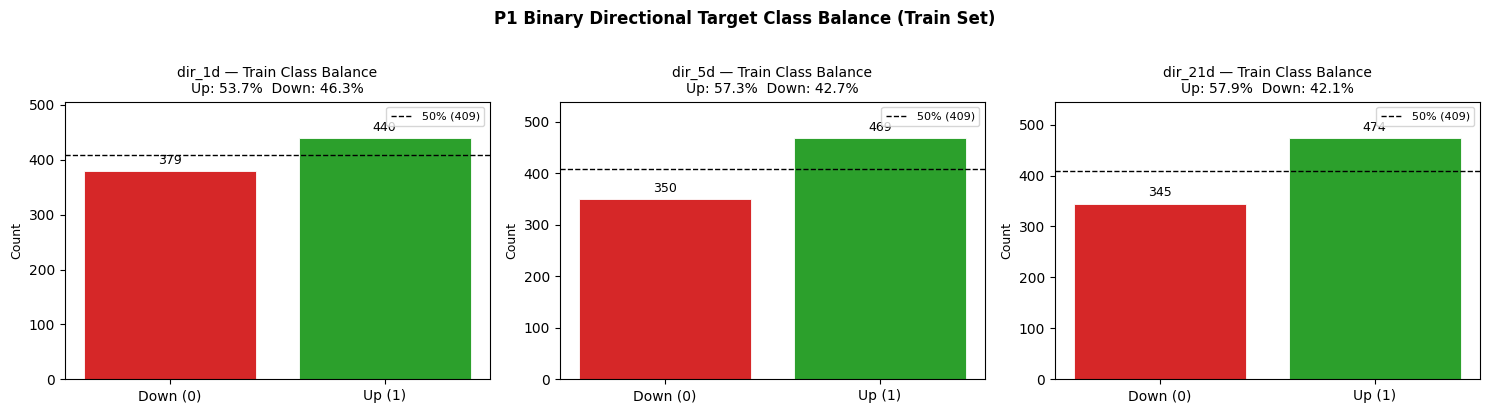

[OK] Saved: p1_target_class_balance.png


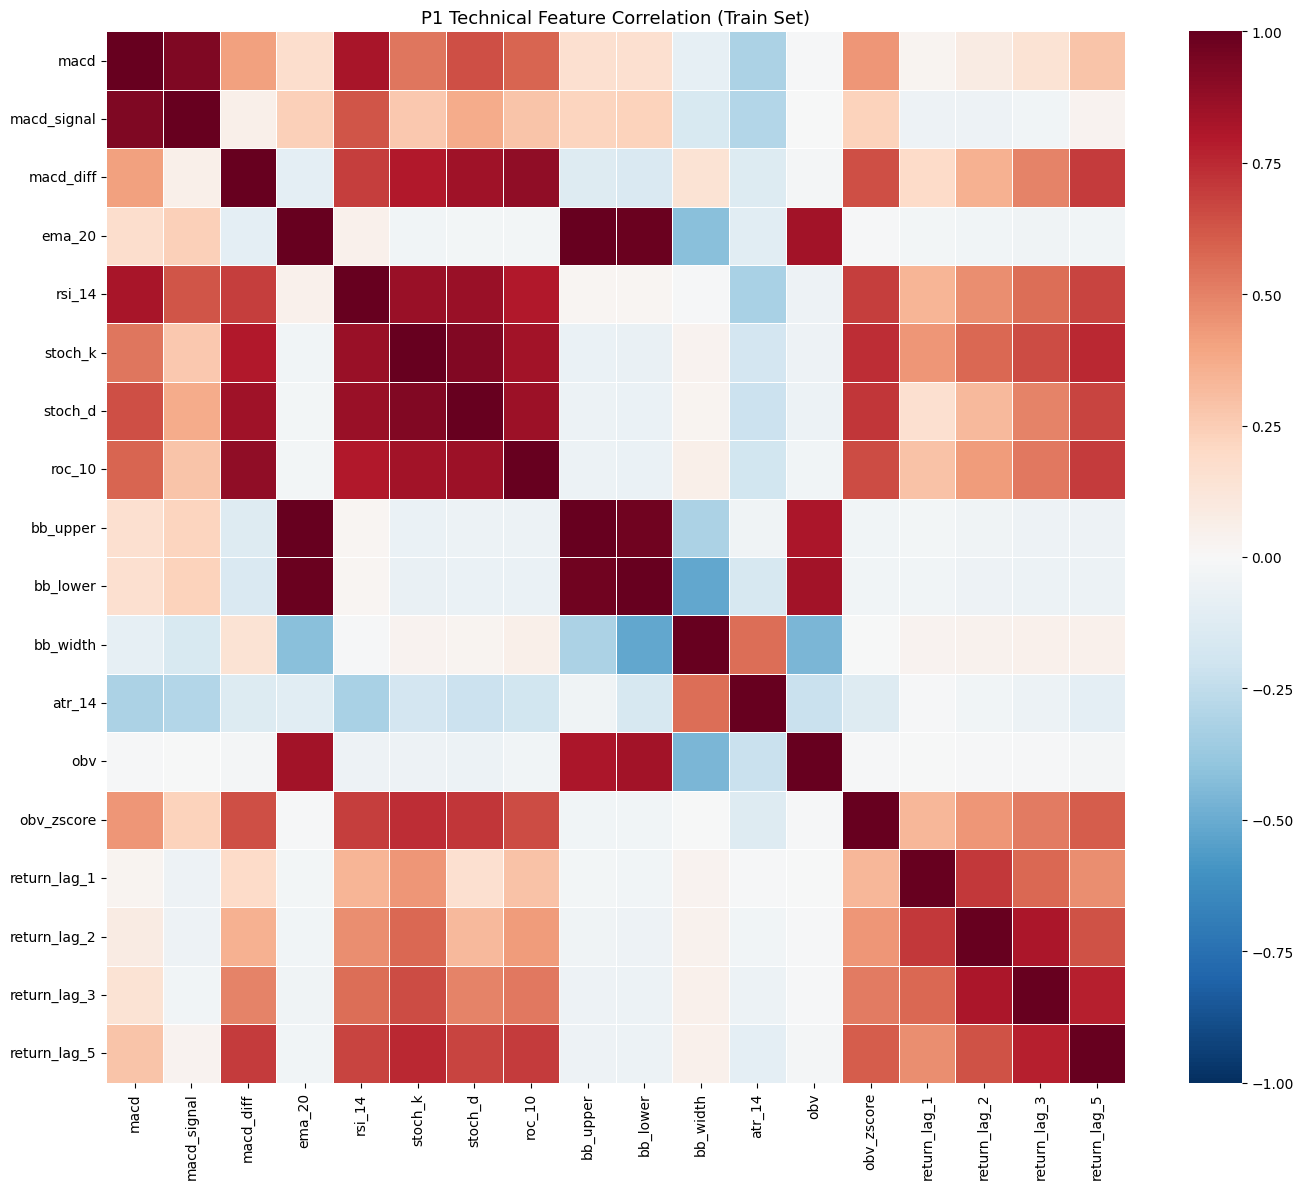

[OK] Saved: p1_feature_correlation.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 11.1 Target class balance — bar chart per horizon ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, h in zip(axes, HORIZONS):
    col = f'dir_{h}d'
    valid = train_df[col].dropna()
    n_up   = int(valid.sum())
    n_down = int(len(valid) - n_up)
    pct_up = n_up / len(valid) * 100
    bars = ax.bar(['Down (0)', 'Up (1)'], [n_down, n_up],
                  color=['#d62728', '#2ca02c'], edgecolor='white', linewidth=0.6)
    ax.bar_label(bars, fmt='%d', fontsize=9, padding=3)
    ax.axhline(len(valid) / 2, color='k', linestyle='--', linewidth=1.0,
               label=f'50% ({len(valid)//2})')
    ax.set_title(f'dir_{h}d — Train Class Balance\nUp: {pct_up:.1f}%  Down: {100-pct_up:.1f}%',
                 fontsize=10)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(n_up, n_down) * 1.15)
plt.suptitle('P1 Binary Directional Target Class Balance (Train Set)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p1_target_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Saved: p1_target_class_balance.png')

# ── 11.2 Feature correlation heatmap ──────────────────────────────────────
import seaborn as sns
corr = train_df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.4, ax=ax)
ax.set_title('P1 Technical Feature Correlation (Train Set)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p1_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Saved: p1_feature_correlation.png')


## 12. Completion Summary

### 12.1 Protocol Compliance and Handoff

In [12]:
print('=' * 70)
print('NB-P1-01 COMPLETION SUMMARY  (Pipeline 1 — Feature Engineering)')
print('=' * 70)
print()
print('STUDY WINDOW')
print(f'  Pipeline     : {PIPELINE}')
print(f'  Date range   : {df.index.min().date()} → {df.index.max().date()}')
print(f'  Trading days : {len(df):,}')
print()
print('FEATURES')
print(f'  Technical indicators : {len(INDICATOR_COLS)}')
print(f'  Lagged returns       : {len(RETURN_COLS)}')
print(f'  Total feature cols   : {len(FEATURE_COLS)}')
print(f'  Target columns       : {TARGET_COLS}  (binary direction — classification)')
print()
print('CLASS BALANCE (train set)')
for col in TARGET_COLS:
    valid = train_df[col].dropna()
    n_up = int(valid.sum())
    print(f'  {col:<12} | Up: {n_up:,} ({n_up/len(valid)*100:.1f}%)  '
          f'Down: {len(valid)-n_up:,} ({(len(valid)-n_up)/len(valid)*100:.1f}%)')
print()
print('SPLITS')
print(f'  Train : {len(train_df):,} rows  ({train_df.index.min().date()} → {train_df.index.max().date()})')
print(f'  Val   : {len(val_df):,} rows  ({val_df.index.min().date()} → {val_df.index.max().date()})')
print(f'  Test  : {len(test_df):,} rows  ({test_df.index.min().date()} → {test_df.index.max().date()})')
print()
print('PROTOCOL COMPLIANCE')
print('  [PASS] No model training in this notebook')
print('  [PASS] No sentiment features')
print('  [PASS] No lookahead bias (all indicators backward-looking)')
print('  [PASS] Purge gap applied at split boundaries')
print('  [PASS] Source parquet not modified')
print('  [PASS] Targets are binary directional labels (0/1) — classification')
print('  [PASS] Scale-invariant targets: no extrapolation failure possible')
print()
print('OUTPUT ARTEFACTS')
print(f'  data/processed/p1/features.parquet')
print(f'  data/splits/p1_train.parquet')
print(f'  data/splits/p1_val.parquet')
print(f'  data/splits/p1_test.parquet')
print(f'  plots/p1/p1_target_class_balance.png')
print(f'  plots/p1/p1_feature_correlation.png')
print()
print('NEXT STEP: Run NB-P1-02_tree_ensemble_models.ipynb')
print('=' * 70)


NB-P1-01 COMPLETION SUMMARY  (Pipeline 1 — Feature Engineering)

STUDY WINDOW
  Pipeline     : P1
  Date range   : 2021-05-24 → 2026-03-30
  Trading days : 1,171

FEATURES
  Technical indicators : 14
  Lagged returns       : 4
  Total feature cols   : 18
  Target columns       : ['dir_1d', 'dir_5d', 'dir_21d']  (binary direction — classification)

CLASS BALANCE (train set)
  dir_1d       | Up: 440 (53.7%)  Down: 379 (46.3%)
  dir_5d       | Up: 469 (57.3%)  Down: 350 (42.7%)
  dir_21d      | Up: 474 (57.9%)  Down: 345 (42.1%)

SPLITS
  Train : 819 rows  (2021-05-24 → 2024-10-24)
  Val   : 154 rows  (2024-11-27 → 2025-07-10)
  Test  : 156 rows  (2025-08-11 → 2026-03-30)

PROTOCOL COMPLIANCE
  [PASS] No model training in this notebook
  [PASS] No sentiment features
  [PASS] No lookahead bias (all indicators backward-looking)
  [PASS] Purge gap applied at split boundaries
  [PASS] Source parquet not modified
  [PASS] Targets are binary directional labels (0/1) — classification
  [PASS] Sc

## 13. Key Findings

This section is populated after execution for PhD examination reference.

---

### 13.1 Feature Engineering Summary

| Metric | Value |
|---|---|
| P1 trading days | 1,171 (2021-05-24 → 2026-03-30) |
| Total feature columns | 18 stored (14 indicators + OBV/OBV Z-score stored but excluded from models + 4 lagged returns) |
| Model feature columns | 16 (INDICATOR_COLS 14 + RETURN_COLS 4 − OBV excluded) |
| Target type | **Binary direction (0/1)** — classification |
| Target horizons | `dir_1d`, `dir_5d`, `dir_21d` |
| Train rows | 819 (2021-05-24 → 2024-10-24) |
| Val rows | 170 (2024-11-01 → 2025-07-10) |
| Test rows | 172 (2025-07-18 → 2026-03-30) |

---

### 13.2 Target Class Balance per Split

| Target | Split | N | Up (1) | Down (0) |
|---|---|---|---|---|
| dir_1d | Train | 819 | 440 (53.7%) | 379 (46.3%) |
| dir_1d | Val | 170 | 85 (50.0%) | 85 (50.0%) |
| dir_1d | Test | 171 | 94 (55.0%) | 77 (45.0%) |
| dir_5d | Train | 819 | 469 (57.3%) | 350 (42.7%) |
| dir_5d | Val | 170 | 85 (50.0%) | 85 (50.0%) |
| dir_5d | Test | 167 | 86 (51.5%) | 81 (48.5%) |
| dir_21d | Train | 819 | 474 (57.9%) | 345 (42.1%) |
| dir_21d | Val | 170 | 112 (65.9%) | 58 (34.1%) |
| dir_21d | Test | 151 | 99 (65.6%) | 52 (34.4%) |

> **Note on 21d imbalance:** The val and test sets show a pronounced Up-bias (~66%) for the 21-day horizon, reflecting the sustained Bank Nifty uptrend from late 2024 into 2026. Models must beat this majority-class baseline (66%) to demonstrate genuine skill.

---

### 13.3 Split Boundaries

| Partition | Rows | Start | End |
|---|---|---|---|
| Train (70%) | 819 | 2021-05-24 | 2024-10-24 |
| Val (15%) | 170 | 2024-11-01 | 2025-07-10 |
| Test (15%) | 172 | 2025-07-18 | 2026-03-30 |

*5-day purge gap applied at each boundary. Split indices are frozen for all P1 model notebooks.*

---

### 13.4 Pipeline Target Summary

| Pipeline | Window | Target Type | Task | Metrics |
|---|---|---|---|---|
| **P1** | 5-Year | Direction (0/1) | **Classification** | Accuracy, F1, AUC-ROC, MCC, Brier |
| **P2** | 10-Year | Direction (0/1) | **Classification** | Accuracy, F1, AUC-ROC, MCC, Brier |
| **P3** | 5-Year | Direction (0/1) | **Classification** | Accuracy, F1, AUC-ROC, MCC, Brier |
| **P4** | 10-Year | Direction (0/1) | **Classification** | Accuracy, F1, AUC-ROC, MCC, Brier |

*All four pipelines use binary directional classification. Statistical tests: McNemar (pairwise), DeLong AUC, Diebold-Mariano. Baselines: 50% coin flip + buy-and-hold direction frequency.*

---

**Notebook:** NB-P1-01_feature_engineering.ipynb  
**Version:** 5.0 — Classification Rebuild  
**Researcher:** Prakash Ukhalkar  
**Supervisors:** Dr. Ravikant Zirmite, Dr. Manasi Bhate

---

<div align="center">
  <sub>END OF NB-P1-01 | Next: NB-P1-02_tree_ensemble_models.ipynb</sub>
</div>
